In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv("/content/student_dataset.csv")
df.head()

,Student_ID,Age,Gender,Daily_Study_Hours,Sleep_Hours,Internet_Hours,Attendance_%,Extracurriculars,Part_time_Job,Final_GPA
0,1,24,Female,2.5,7.2,6.9,76.0,2,No,5.36
1,2,21,Female,3.7,7.2,0.0,68.7,4,Yes,6.79
2,3,22,Other,4.8,7.1,2.9,71.5,2,No,9.27
3,4,24,Male,5.4,7.6,2.3,60.9,1,No,7.62
4,5,20,Other,0.7,8.2,4.4,79.2,0,No,7.35


In [3]:
df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Daily_Study_Hours,0
Sleep_Hours,0
Internet_Hours,0
Attendance_%,0
Extracurriculars,0
Part_time_Job,0
Final_GPA,0


In [7]:
df.describe()

,Student_ID,Age,Daily_Study_Hours,Sleep_Hours,Internet_Hours,Attendance_%,Extracurriculars,Final_GPA
count,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,20.9600,2.961500,6.985900,4.034800,79.717400,1.884000,6.981840
std,288.819436,2.0036,1.444879,0.974957,1.962504,9.627581,1.426387,1.471539
min,1.000000,18.0000,0.000000,4.000000,0.000000,50.000000,0.000000,4.000000
25%,250.750000,19.0000,1.900000,6.300000,2.700000,73.300000,1.000000,5.950000
50%,500.500000,21.0000,3.000000,7.000000,4.000000,79.900000,2.000000,6.945000
75%,750.250000,23.0000,3.900000,7.700000,5.400000,86.300000,3.000000,8.020000
max,1000.000000,24.0000,7.100000,10.000000,9.500000,100.000000,4.000000,10.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   object 
 3   Daily_Study_Hours  1000 non-null   float64
 4   Sleep_Hours        1000 non-null   float64
 5   Internet_Hours     1000 non-null   float64
 6   Attendance_%       1000 non-null   float64
 7   Extracurriculars   1000 non-null   int64  
 8   Part_time_Job      1000 non-null   object 
 9   Final_GPA          1000 non-null   float64
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


In [9]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Daily_Study_Hours,0
Sleep_Hours,0
Internet_Hours,0
Attendance_%,0
Extracurriculars,0
Part_time_Job,0
Final_GPA,0


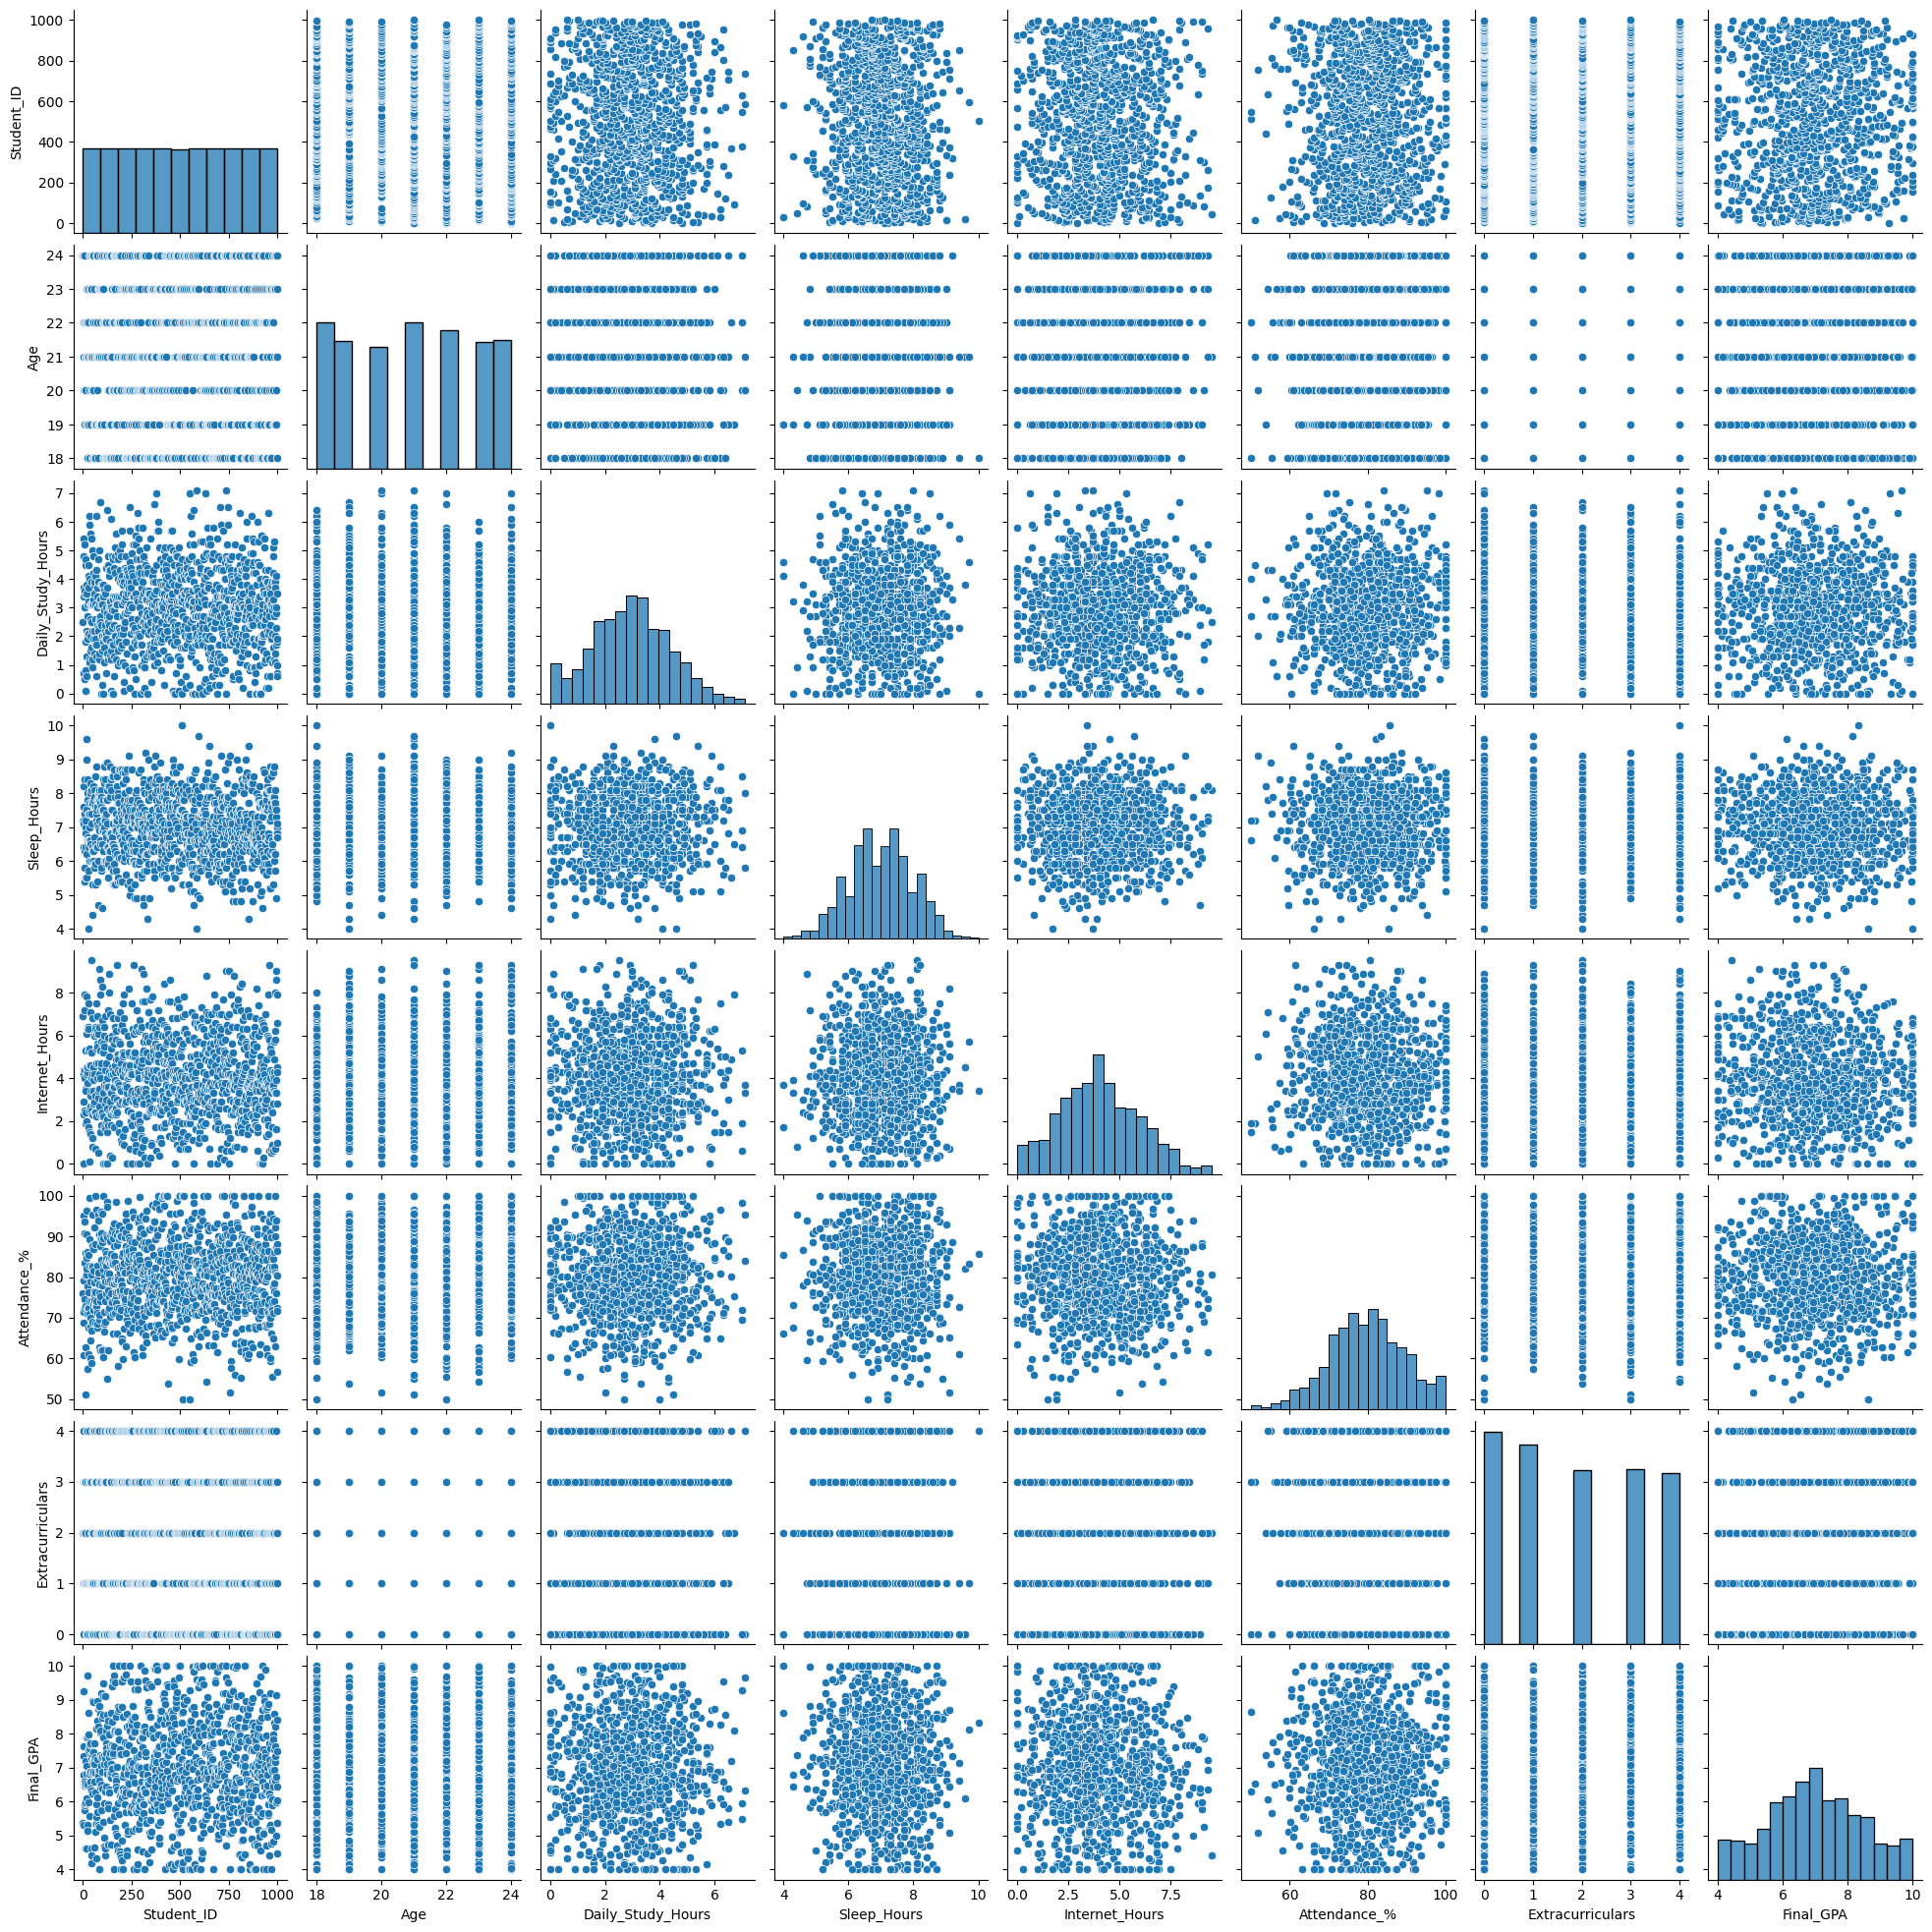

In [10]:
sns.pairplot(df)
plt.show()

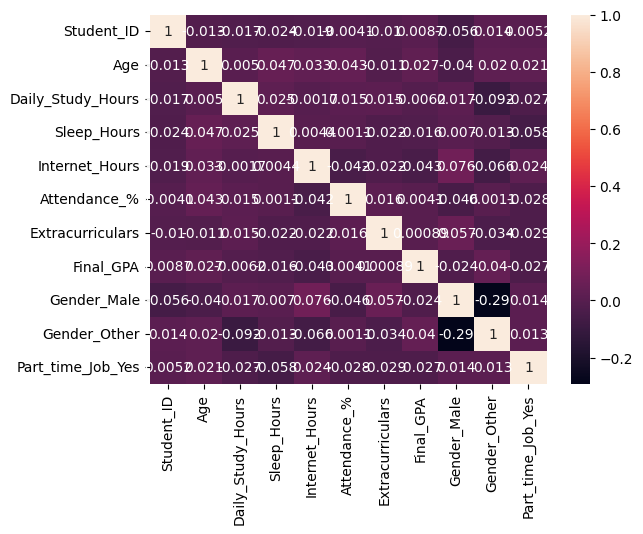

In [15]:
sns.heatmap(df_encoded.corr(), annot=True)
plt.show()

In [16]:
df = df.dropna()

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
X = df.drop("Final_GPA", axis=1)
y = df["Final_GPA"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2.2541608247487863
R2 Score: -0.022210351085117708


In [25]:
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_})
print(coefficients.sort_values(by="Coefficient", ascending=False))

             Feature  Coefficient
8       Gender_Other     0.020869
1                Age     0.008424
6   Extracurriculars     0.002910
0         Student_ID     0.000128
5       Attendance_%    -0.001543
2  Daily_Study_Hours    -0.012603
3        Sleep_Hours    -0.024973
4     Internet_Hours    -0.043458
7        Gender_Male    -0.103120
9  Part_time_Job_Yes    -0.150298
